In [1]:
pip install -U mplhep

Note: you may need to restart the kernel to use updated packages.


In [2]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
import mplhep as hep
import yaml
from sidm.tools.utilities import plot_data_mc

In [3]:
yaml_file_path = '../../configs/ntuples/signal_2mu2e_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_2mu2e_all = list(data["llpNanoAOD_v2"]["samples"].keys())

yaml_file_path = '../../configs/ntuples/signal_4mu_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_4mu_all = list(data["llpNanoAOD_v2"]["samples"].keys())

In [4]:
samples_bkg = [
    "TTJets",
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120", 
    "QCD_Pt120To170",
    "QCD_Pt170To300", 
    "QCD_Pt300To470",
    "QCD_Pt470To600", 
    "QCD_Pt600To800", 
    "QCD_Pt800To1000",
    "QCD_Pt1000", 
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50", 
]

samples_data= [ 
    "DoubleMuon_2018C",
    
    "DoubleMuon_2018A_0",
    "DoubleMuon_2018A_1",
    "DoubleMuon_2018A_2",
]

In [5]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in signals_2mu2e_all:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "signal_2mu2e.coffea"
        try: 
            output = coffea.util.load("data_control_region_1muLj_CV/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for sample 2Mu2E_100GeV_0p25GeV_0p02mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_0p2mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_2p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_10p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_0p25GeV_20p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_0p096mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_0p96mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_9p6mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_48p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_1p2GeV_96p0mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0GeV_0p4mm
Successfully opened file
Loading file for sample 2Mu2E_100GeV_5p0G

In [6]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}
    
#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in signals_4mu_all:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = "signal_4mu.coffea"
        try: 
            output = coffea.util.load("data_control_region_1muLj_CV/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample 4Mu_100GeV_0p25GeV_0p02mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_0p2mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_2p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_10p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_0p25GeV_20p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_0p096mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_0p96mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_9p6mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_48p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_1p2GeV_96p0mm
Successfully opened file
Loading file for sample 4Mu_100GeV_5p0GeV_0p4mm
Successfully opened file
Loading file for sample 4Mu_100GeV_5p0GeV_4p0mm
Successfully opened file
Loading file for sample 4Mu_1

In [7]:
#First check if there is already an out dictionary
try:
    out
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for sample in samples_bkg:
    if sample in out:
        print(f"{sample} already found in memory; not loading file")
    else:
        print(f"Loading file for sample {sample}")
        filename = sample + ".coffea"
        try: 
            output = coffea.util.load("data_control_region_1muLj_CV/"+filename)
            print("Successfully opened file")        
            out[sample] = output["out"][sample]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out[sample] = output[sample]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

The _out_ dictionary already exists; will use what is saved in memory if possible
Loading file for sample TTJets
Successfully opened file
Loading file for sample QCD_Pt15To20
Successfully opened file
Loading file for sample QCD_Pt20To30
Successfully opened file
Loading file for sample QCD_Pt30To50
Successfully opened file
Loading file for sample QCD_Pt50To80
Successfully opened file
Loading file for sample QCD_Pt80To120
Successfully opened file
Loading file for sample QCD_Pt120To170
Successfully opened file
Loading file for sample QCD_Pt170To300
Successfully opened file
Loading file for sample QCD_Pt300To470
Successfully opened file
Loading file for sample QCD_Pt470To600
Successfully opened file
Loading file for sample QCD_Pt600To800
Successfully opened file
Loading file for sample QCD_Pt800To1000
Successfully opened file
Loading file for sample QCD_Pt1000
Successfully opened file
Loading file for sample DYJetsToMuMu_M10to50
Successfully opened file
Loading file for sample DYJetsToMuMu

In [8]:
#First check if there is already an out dictionary
try:
    out_data
    print("The _out_ dictionary already exists; will use what is saved in memory if possible")
except NameError:
    print("WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead")
    out_data = {}

#For each sample, try to use the data in memory if possible; if not try to load the file
#If those both fail, then raise an error and skip it
for data in samples_data:
    if data in out_data:
        print(f"{data} already found in memory; not loading file")
    else:
        print(f"Loading file for data {data}")
        filename = data + ".coffea"
        try: 
            output = coffea.util.load("data_control_region_1muLj_CV/"+filename)
            print("Successfully opened file")        
            out_data[data] = output["out"][data]
            # out[sample] = output["out"][sample.removesuffix("_part1")]
        except Exception:
            out_data[data] = output[data]
            # print("**** ERROR! File not found. Check the file name, or run the processor again and save the output to a pickle file using coffea.util.save")

WARNING! No processor output stored in the kernel's memory. Will try to load pickled coffea file for each sample instead
Loading file for data DoubleMuon_2018C
Successfully opened file
Loading file for data DoubleMuon_2018A_0
Successfully opened file
Loading file for data DoubleMuon_2018A_1
Successfully opened file
Loading file for data DoubleMuon_2018A_2
Successfully opened file


In [9]:
channels = [
    "data_control_region_1muLj_cosmic_veto",
]

In [10]:
QCD = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt1000",
]

DY = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
]

TT = ["TTJets"]

In [11]:
backgrounds = {
    "TT": TT,
    r"DY $\rightarrow \mu\mu$": DY,
    "QCD": QCD,
}

background_colors = {
    "TT": "#717581",
    r"DY $\rightarrow \mu\mu$": "#3f90da",
    "QCD": "#b9ac70",
}

signal_maps = {
    "2Mu2E": ["2Mu2E_100GeV_5p0GeV_40p0mm", "2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_1000GeV_0p25GeV_0p2mm"],
    "4Mu": ["4Mu_100GeV_5p0GeV_40p0mm", "4Mu_500GeV_1p2GeV_1p9mm", "4Mu_1000GeV_0p25GeV_0p2mm"],
}

signal_colors = ["r", "orange", "gold", "lime", "cyan", "magenta"]

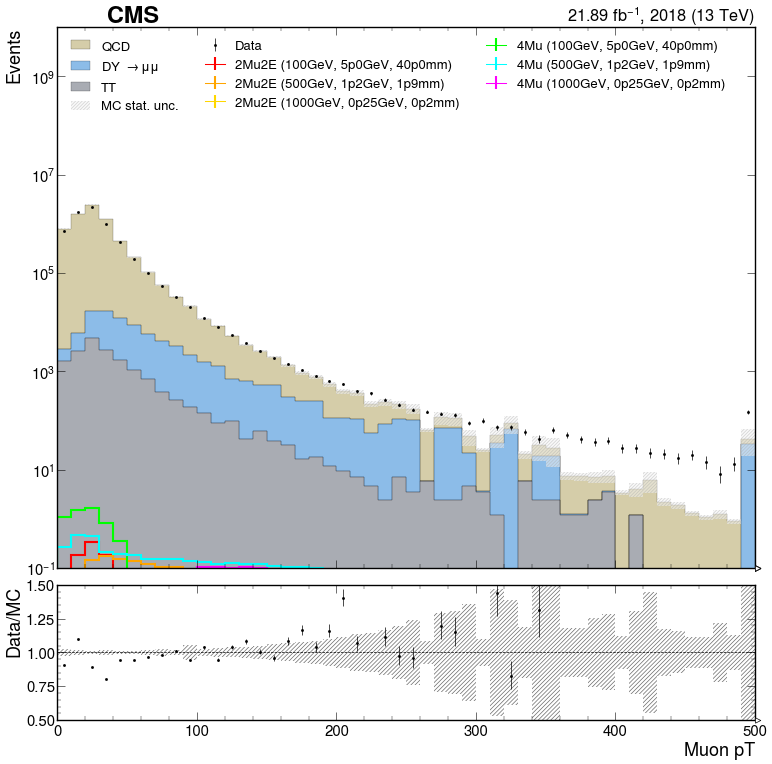

In [13]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="muon_pt",
    xlabel=r"Muon pT",
)

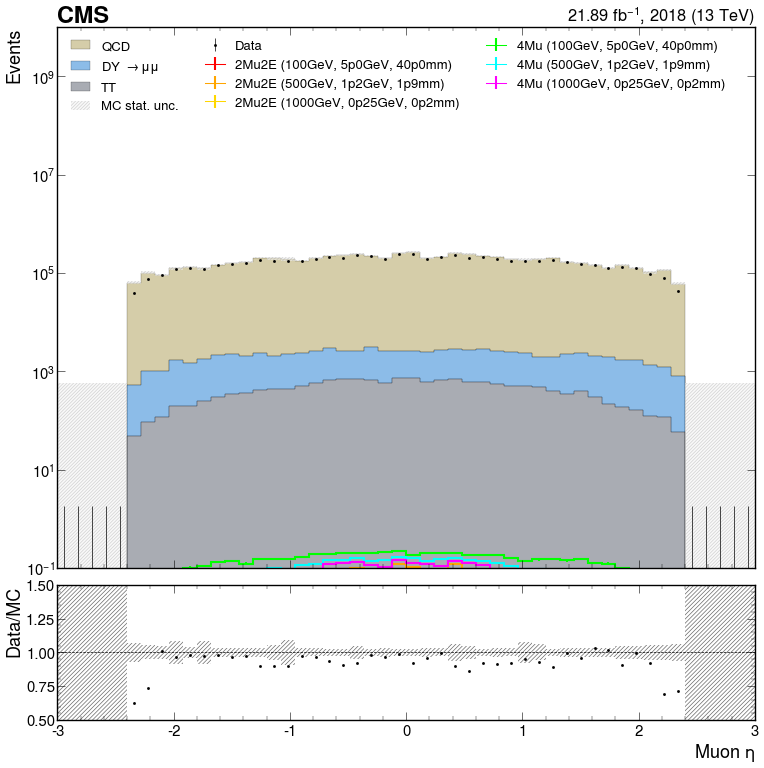

In [14]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="muon_eta",
    xlabel=r"Muon $\eta$",
)

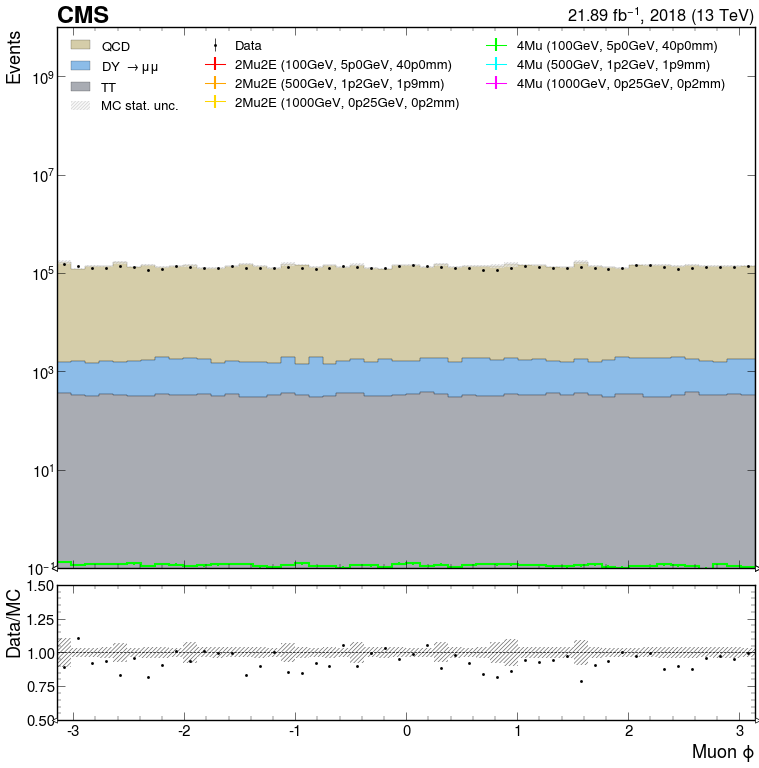

In [15]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="muon_phi",
    xlabel=r"Muon $\phi$",
)

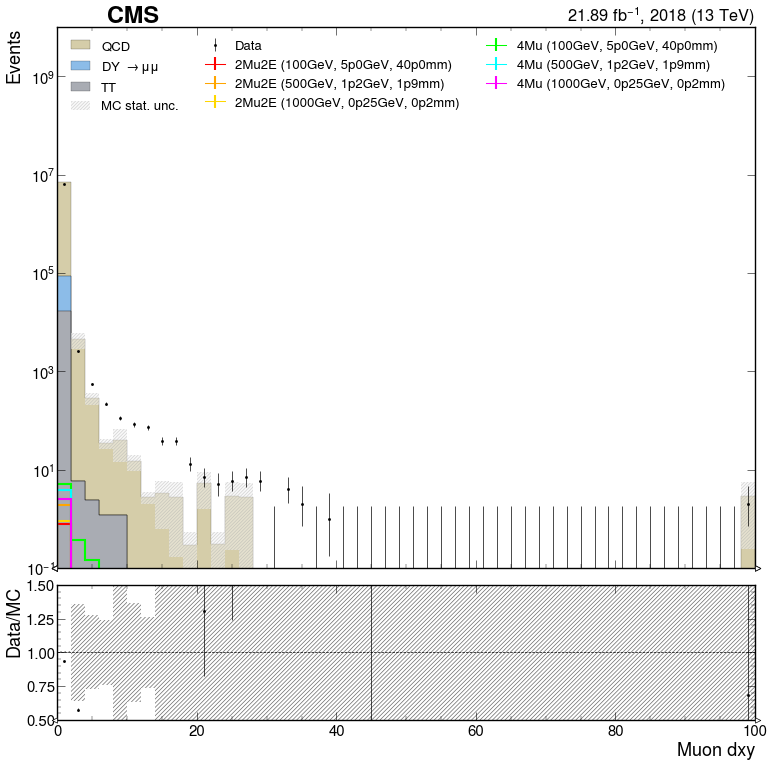

In [16]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="muon_dxy",
    xlabel=r"Muon dxy",
)

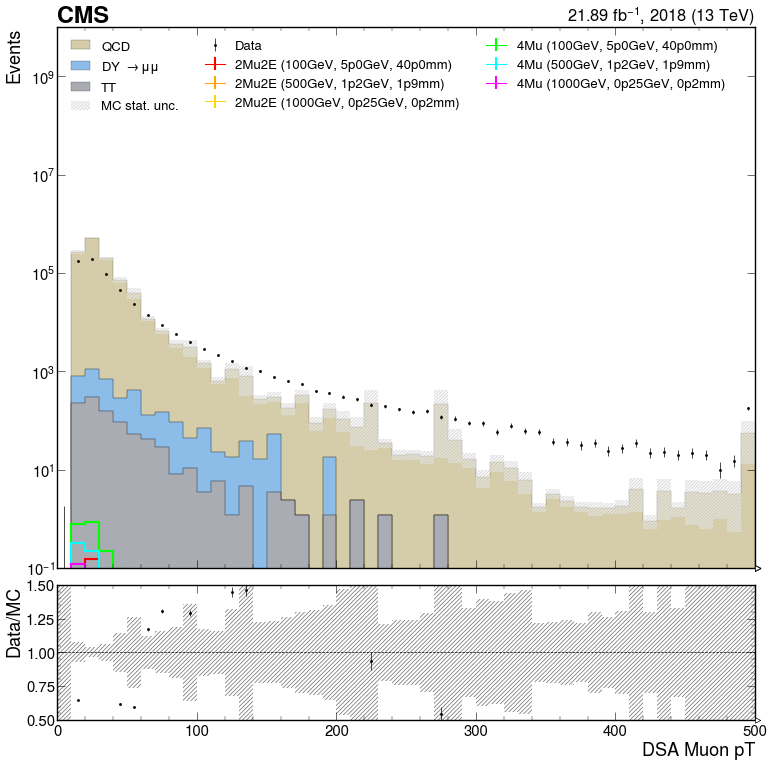

In [17]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsaMuon_pt",
    xlabel=r"DSA Muon pT",
)

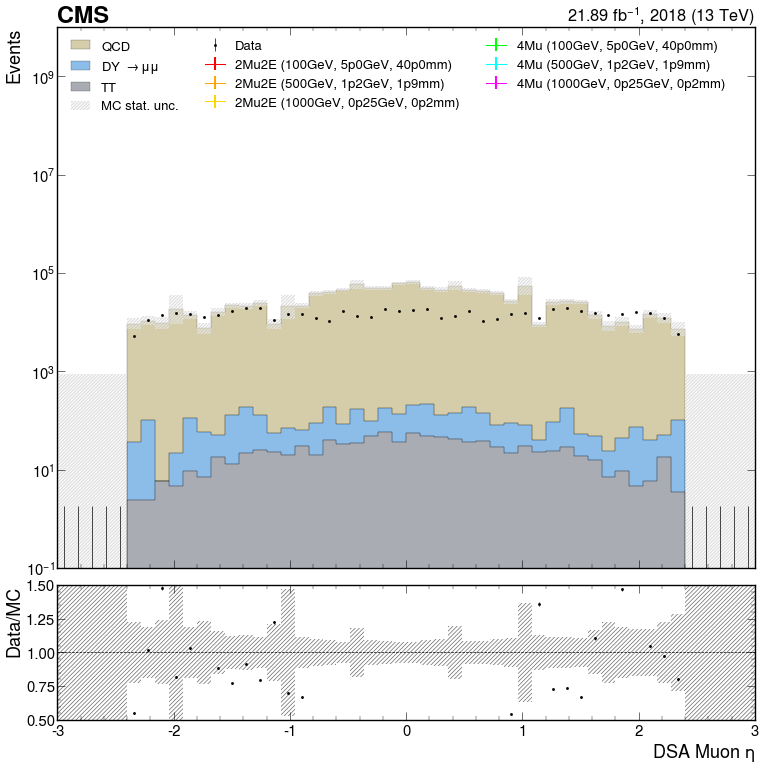

In [18]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsaMuon_eta",
    xlabel=r"DSA Muon $\eta$",
)

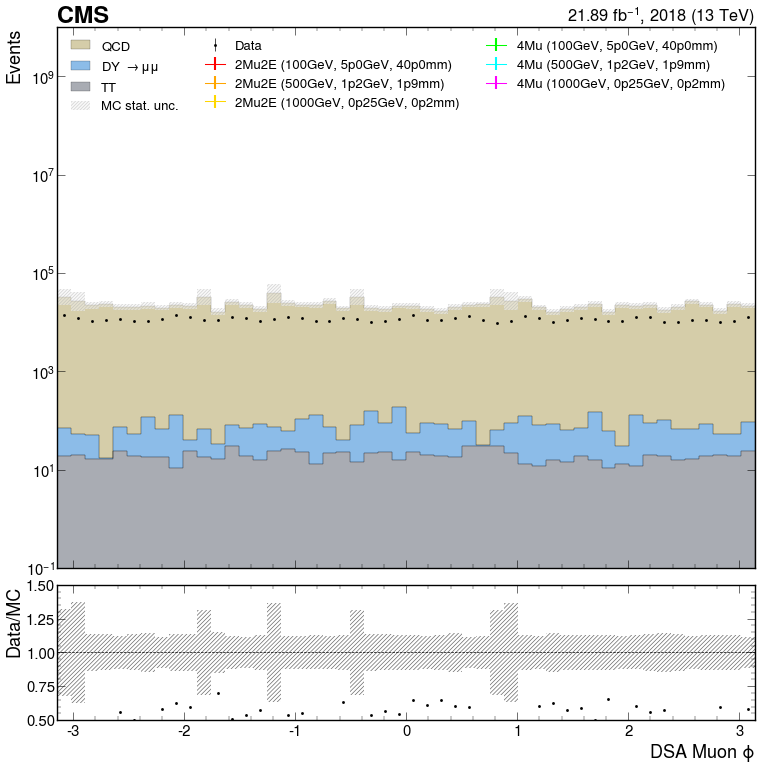

In [19]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsaMuon_phi",
    xlabel=r"DSA Muon $\phi$",
)

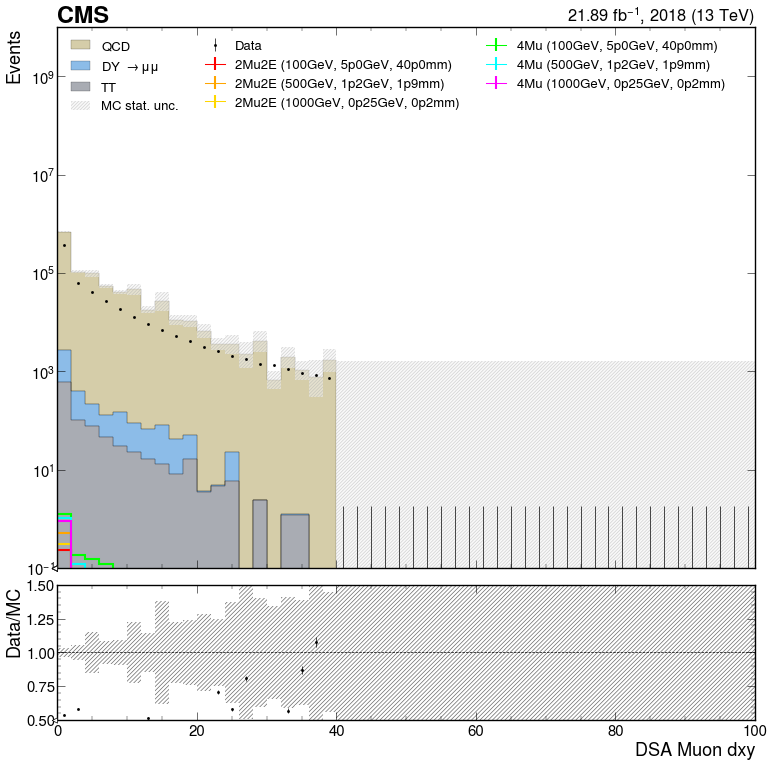

In [20]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsaMuon_dxy",
    xlabel=r"DSA Muon dxy",
)

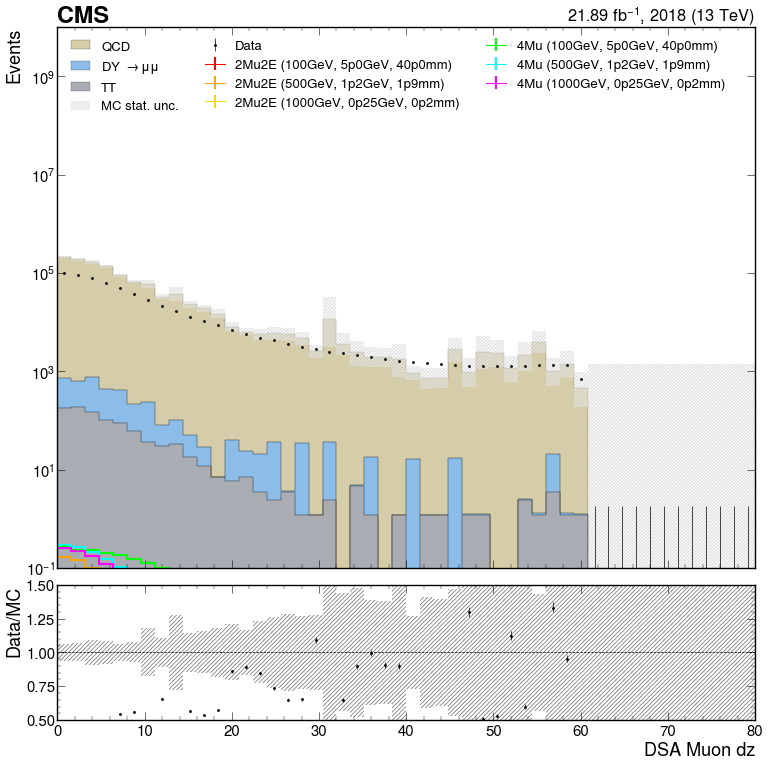

In [21]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsaMuon_dz",
    xlabel=r"DSA Muon dz",
)

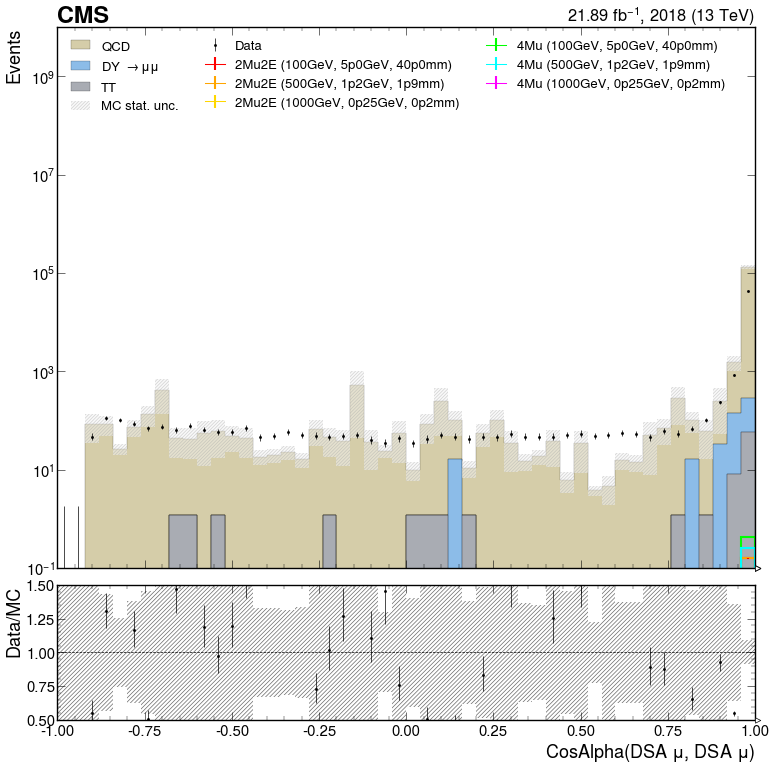

In [22]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsaMu_dsaMu_cosAlpha",
    xlabel=r"CosAlpha(DSA $\mu$, DSA $\mu$)",
)

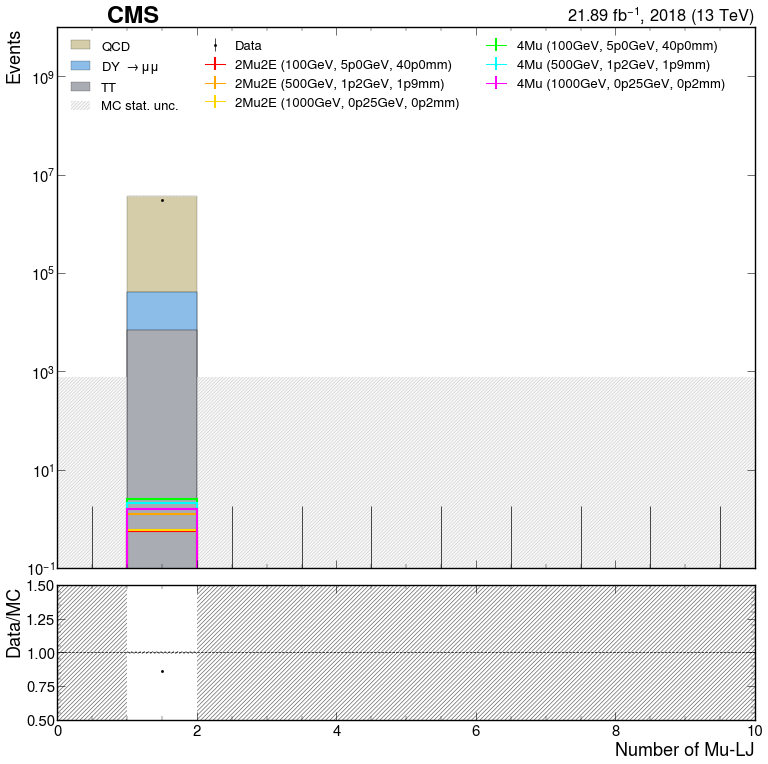

In [23]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_n",
    xlabel=r"Number of Mu-LJ",
)

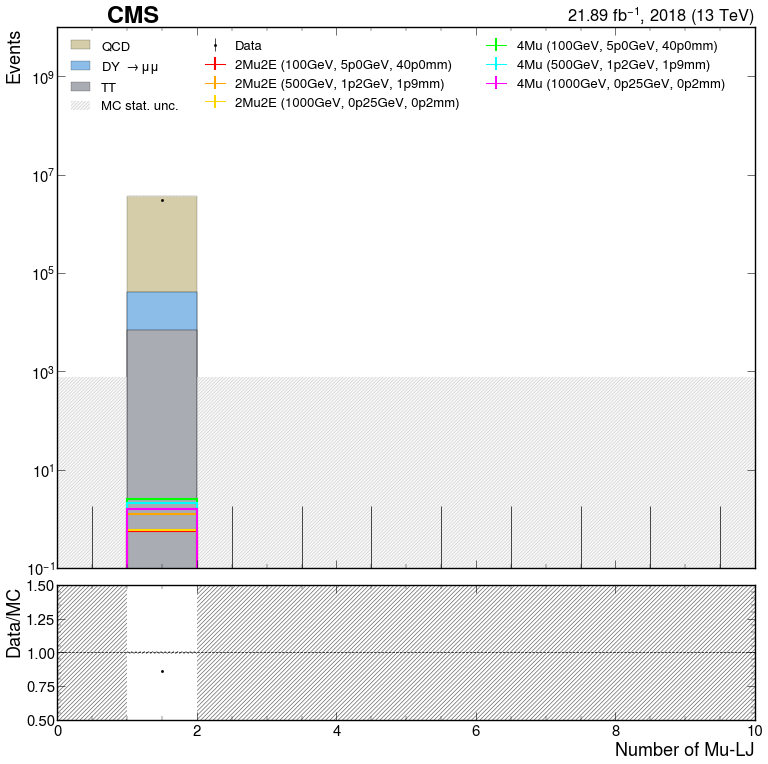

In [24]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_n_test",
    xlabel=r"Number of Mu-LJ",
)

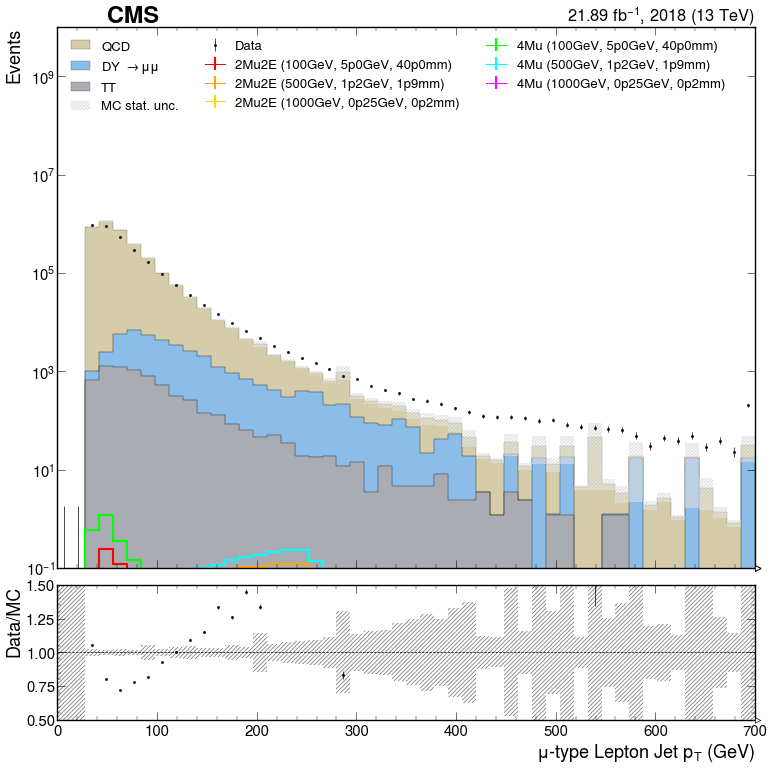

In [25]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_pt",
    xlabel=r"$\mu$-type Lepton Jet $p_T$ (GeV)",
)

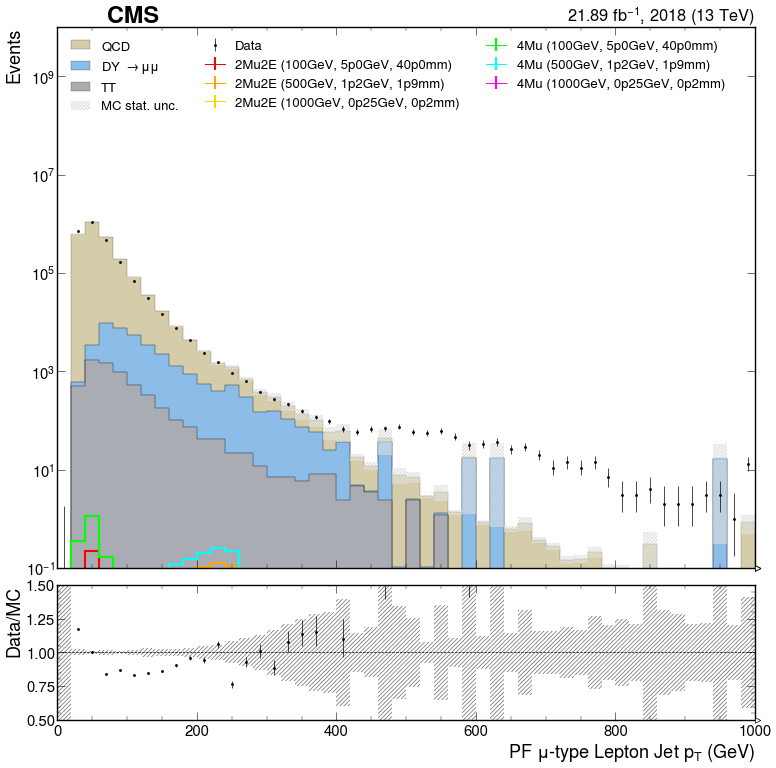

In [26]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_lj_pt",
    xlabel=r"PF $\mu$-type Lepton Jet $p_T$ (GeV)",
)

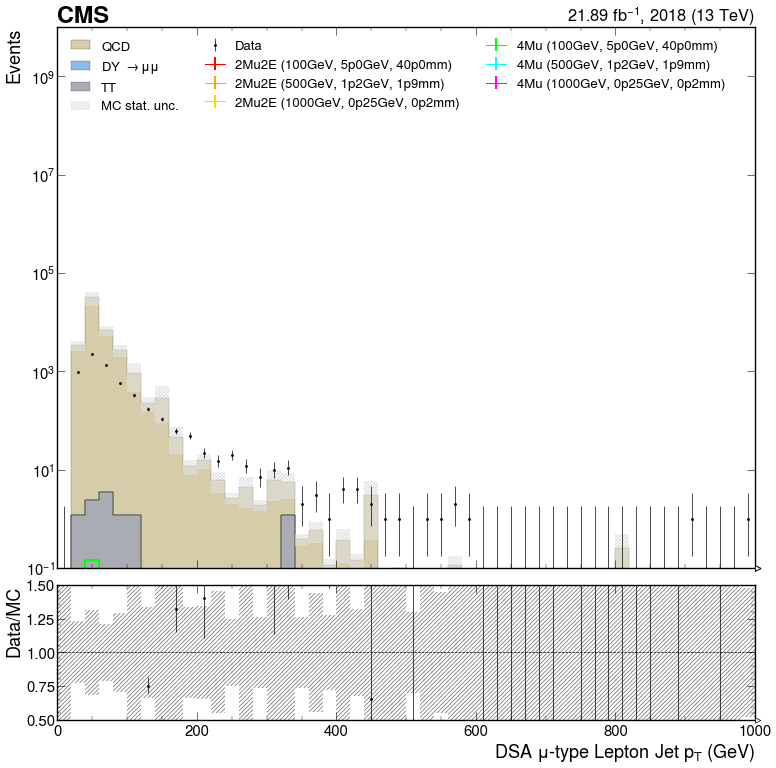

In [27]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_lj_pt",
    xlabel=r"DSA $\mu$-type Lepton Jet $p_T$ (GeV)",
)

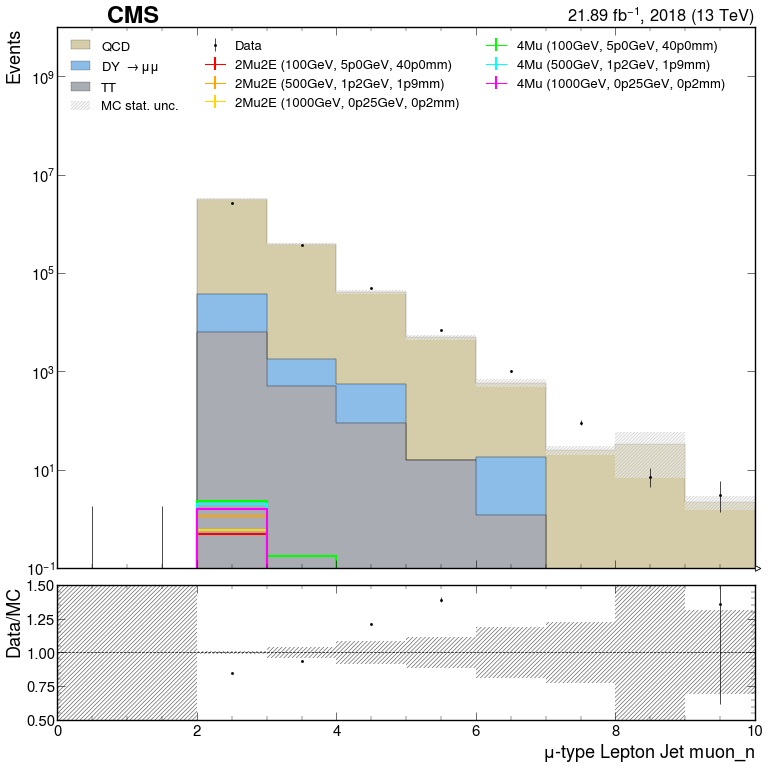

In [28]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_muonN",
    xlabel=r"$\mu$-type Lepton Jet muon_n",
)

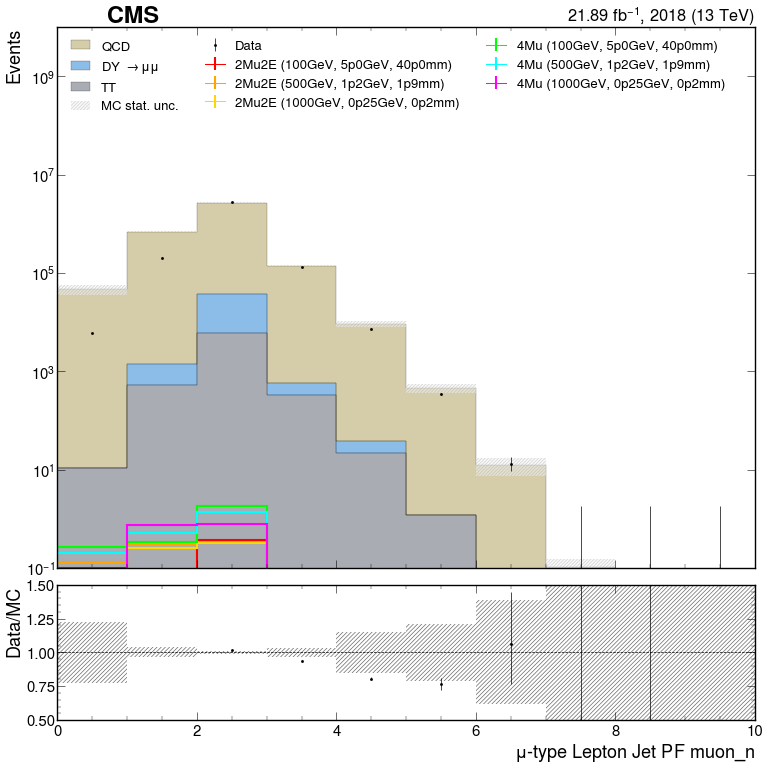

In [29]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_pfMu_n",
    xlabel=r"$\mu$-type Lepton Jet PF muon_n",
)

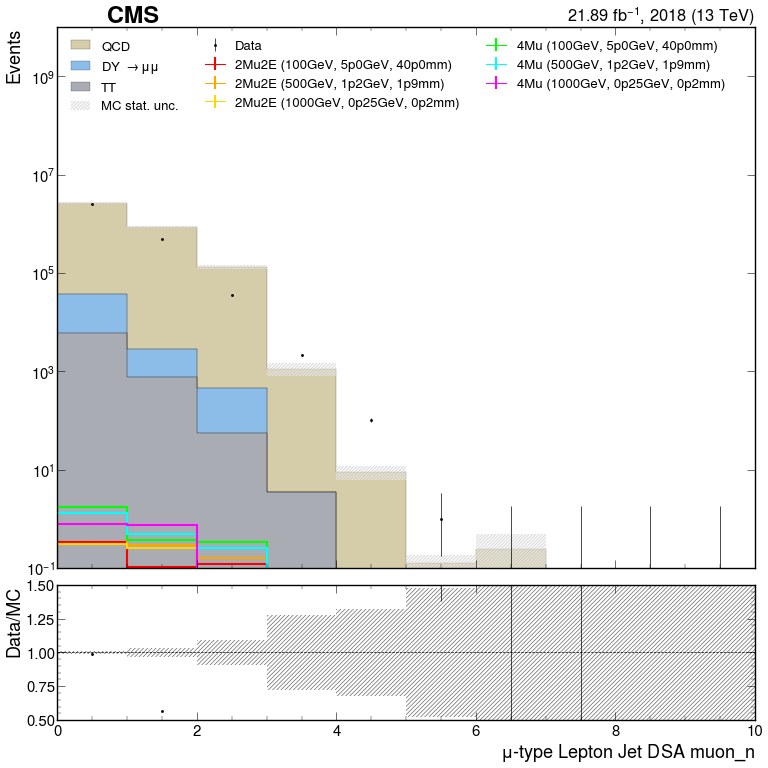

In [30]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_dsaMu_n",
    xlabel=r"$\mu$-type Lepton Jet DSA muon_n",
)

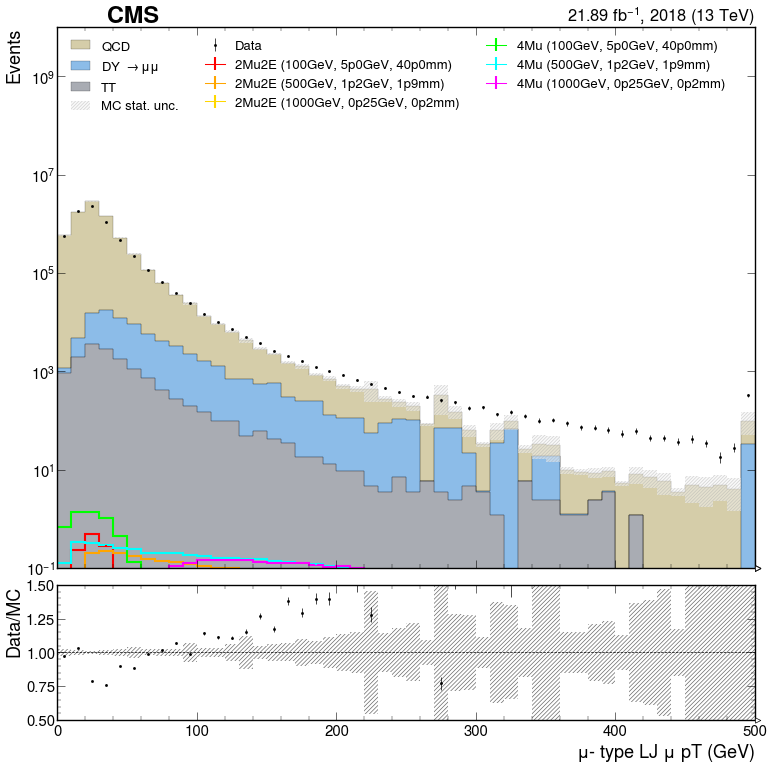

In [31]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_muon_pt",
    xlabel=r"$\mu$- type LJ $\mu$ pT (GeV)",
)

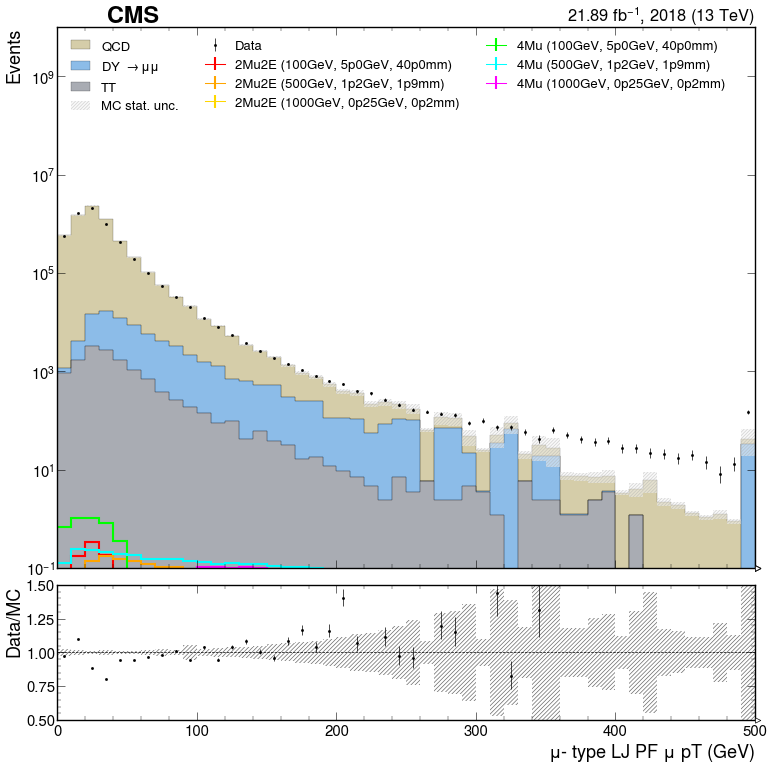

In [32]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_pfMuon_pt",
    xlabel=r"$\mu$- type LJ PF $\mu$ pT (GeV)",
)

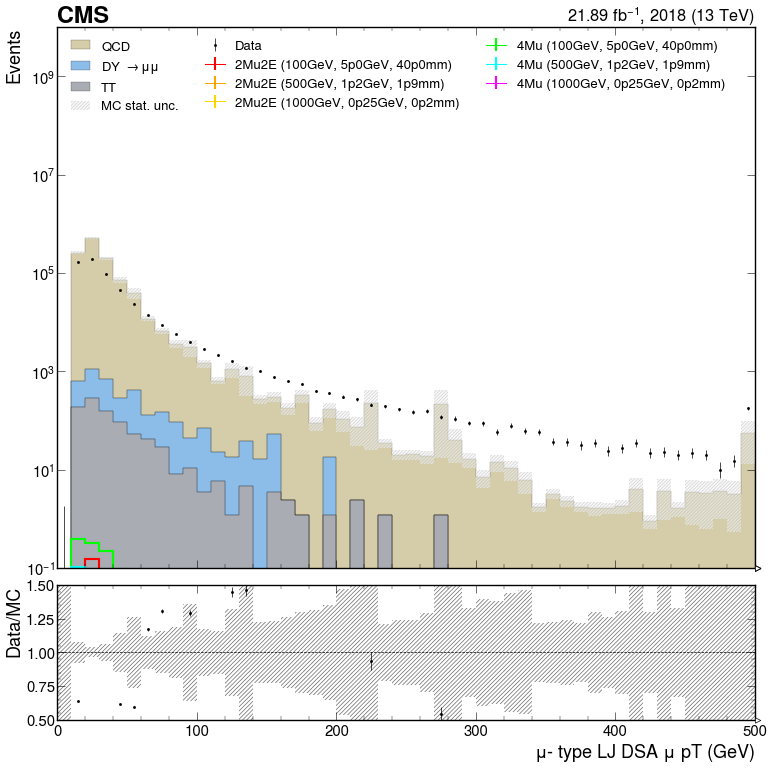

In [33]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_dsaMuon_pt",
    xlabel=r"$\mu$- type LJ DSA $\mu$ pT (GeV)",
)

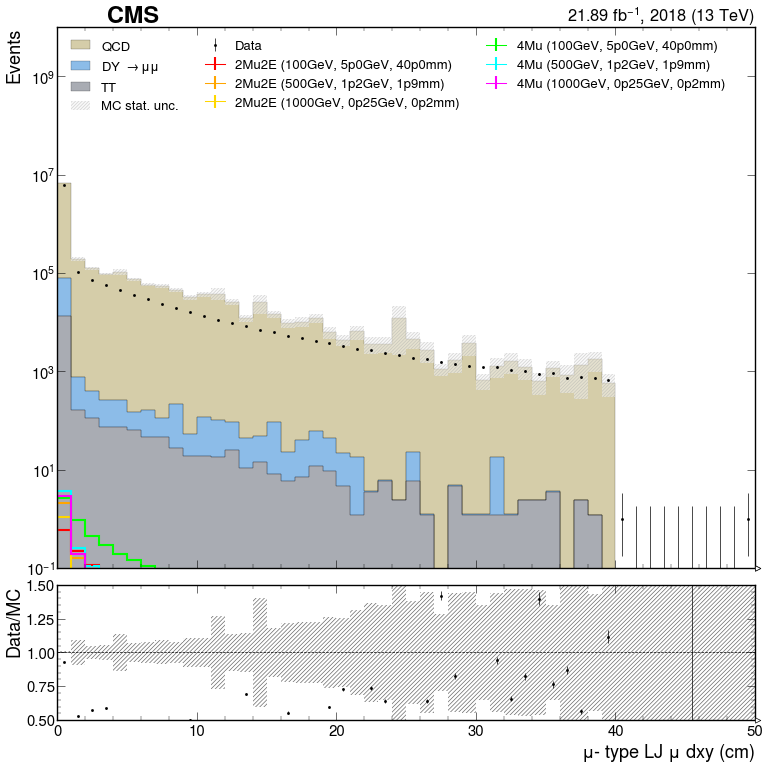

In [34]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_muon_dxy",
    xlabel=r"$\mu$- type LJ $\mu$ dxy (cm)",
)

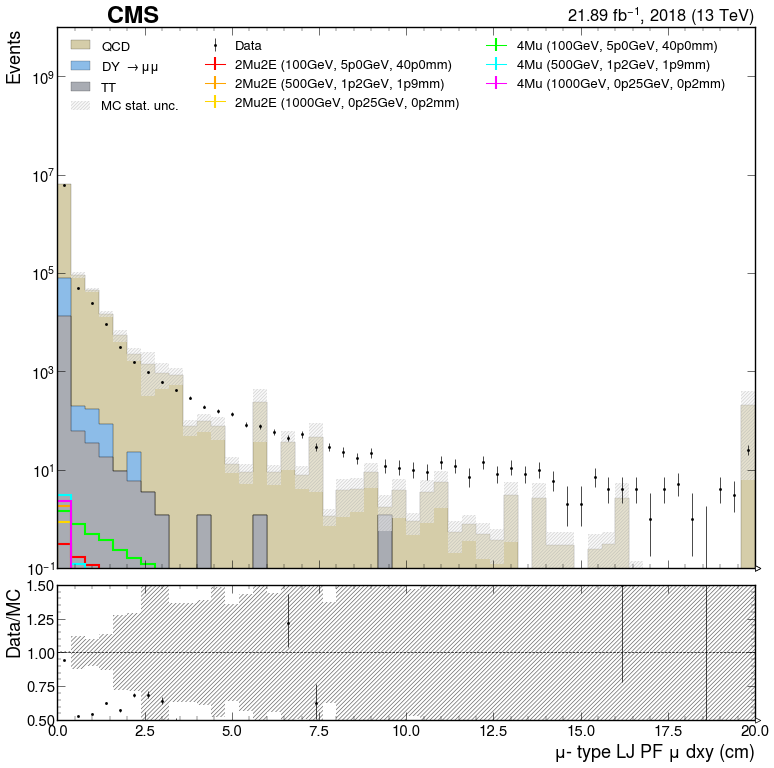

In [35]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_pfMuon_dxy",
    xlabel=r"$\mu$- type LJ PF $\mu$ dxy (cm)",
)

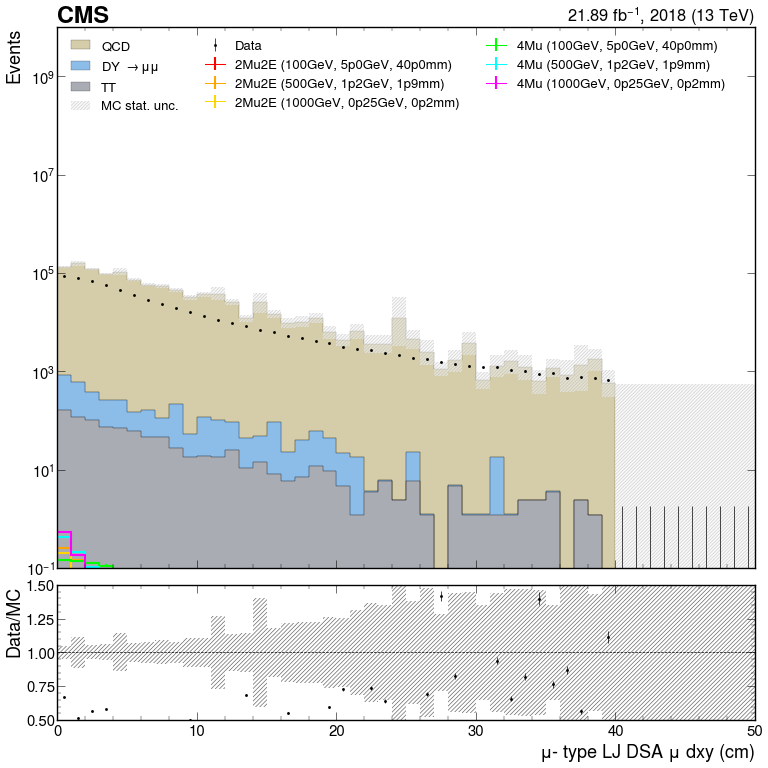

In [36]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_dsaMuon_dxy",
    xlabel=r"$\mu$- type LJ DSA $\mu$ dxy (cm)",
)

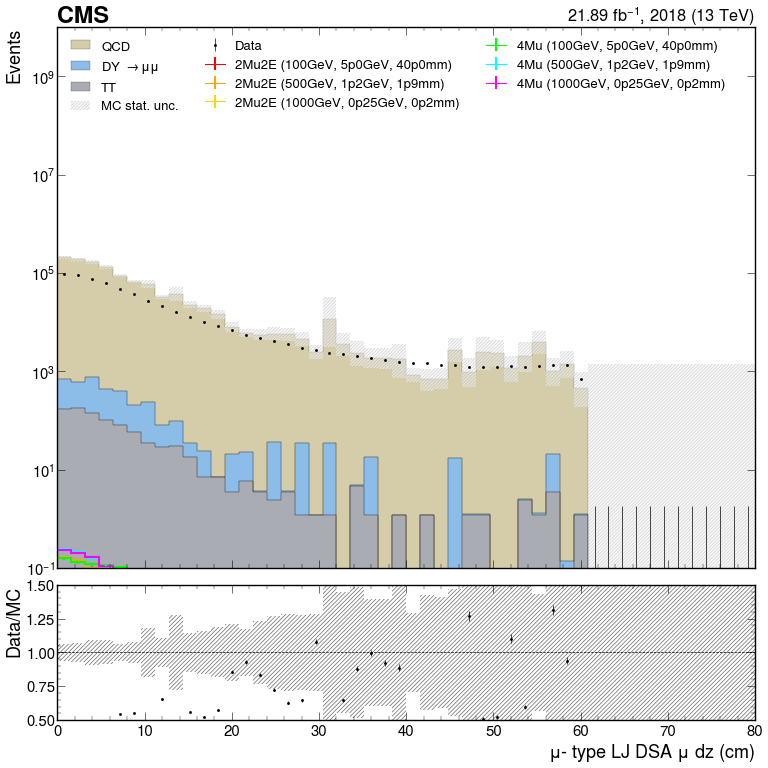

In [37]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_dsaMuon_dz",
    xlabel=r"$\mu$- type LJ DSA $\mu$ dz (cm)",
)

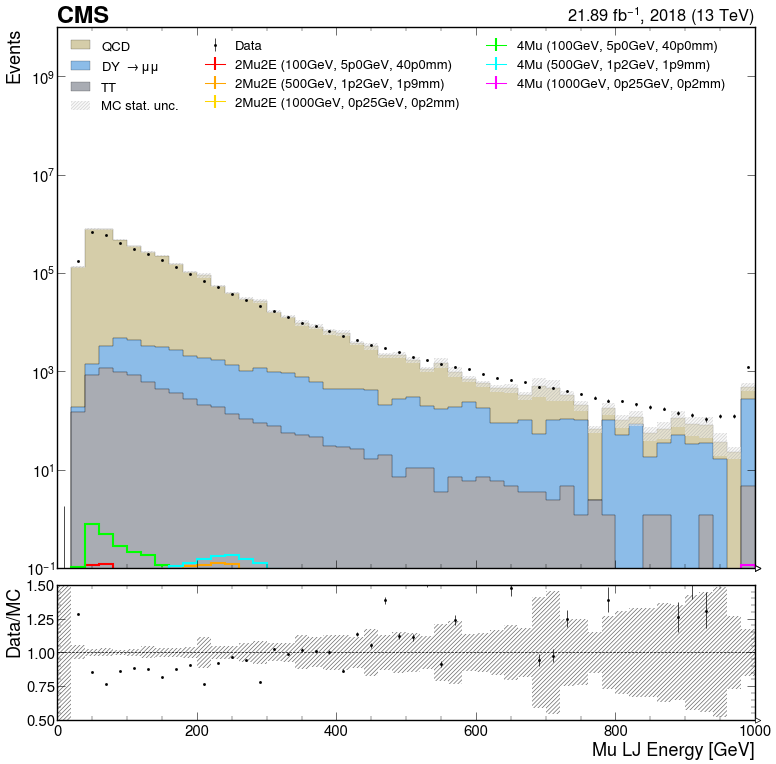

In [38]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_e",
    xlabel=r"Mu LJ Energy [GeV]",
)

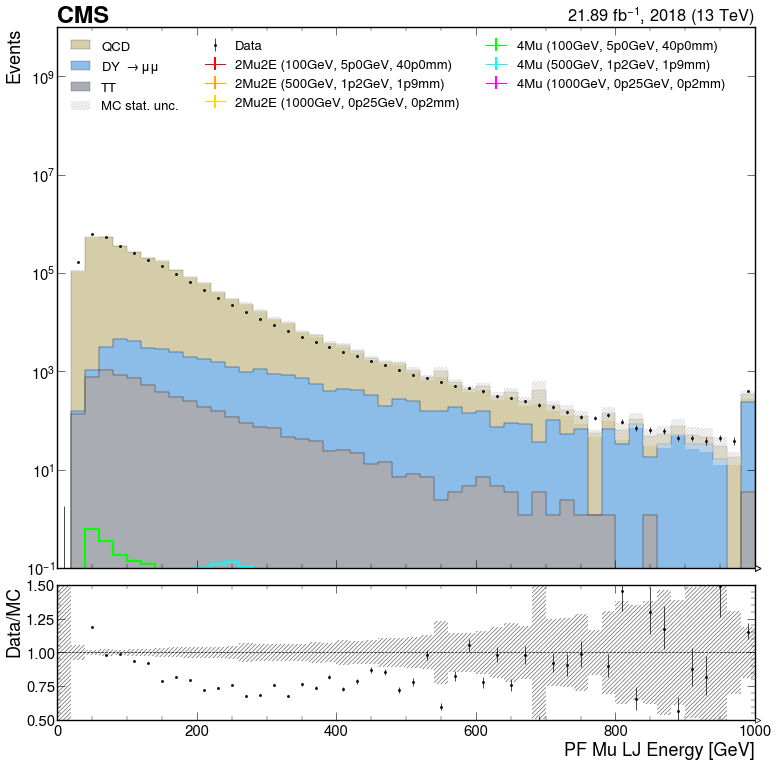

In [39]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_lj_e",
    xlabel=r"PF Mu LJ Energy [GeV]",
)

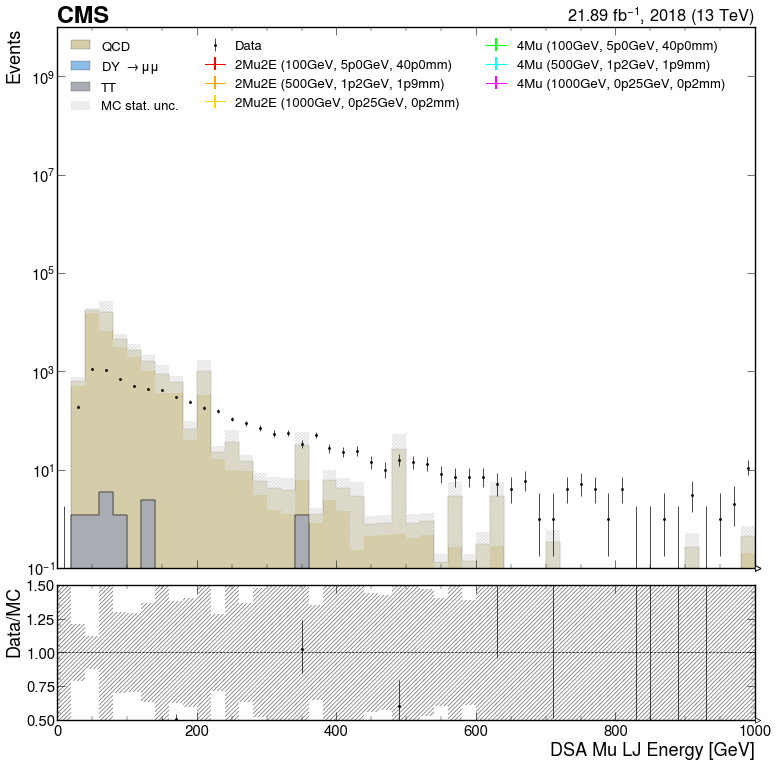

In [40]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_lj_e",
    xlabel=r"DSA Mu LJ Energy [GeV]",
)

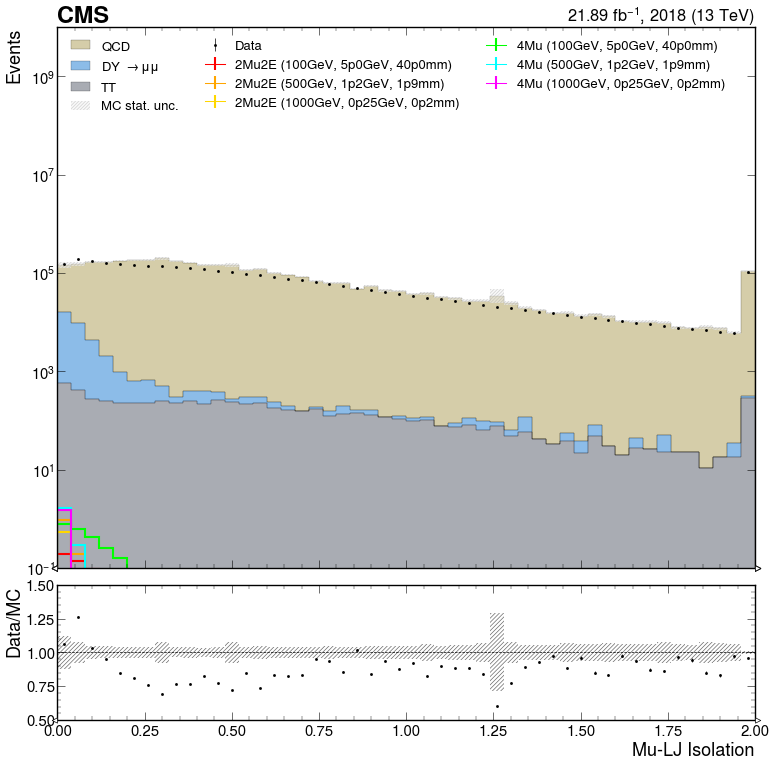

In [41]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_lj_iso",
    xlabel=r"Mu-LJ Isolation",
)

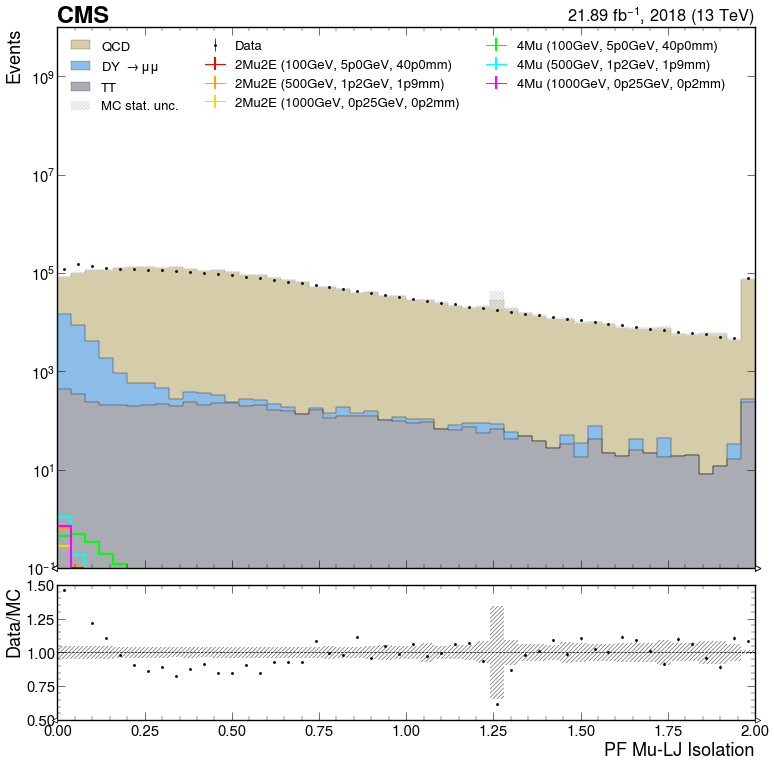

In [42]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_lj_isolation",
    xlabel=r"PF Mu-LJ Isolation",
)

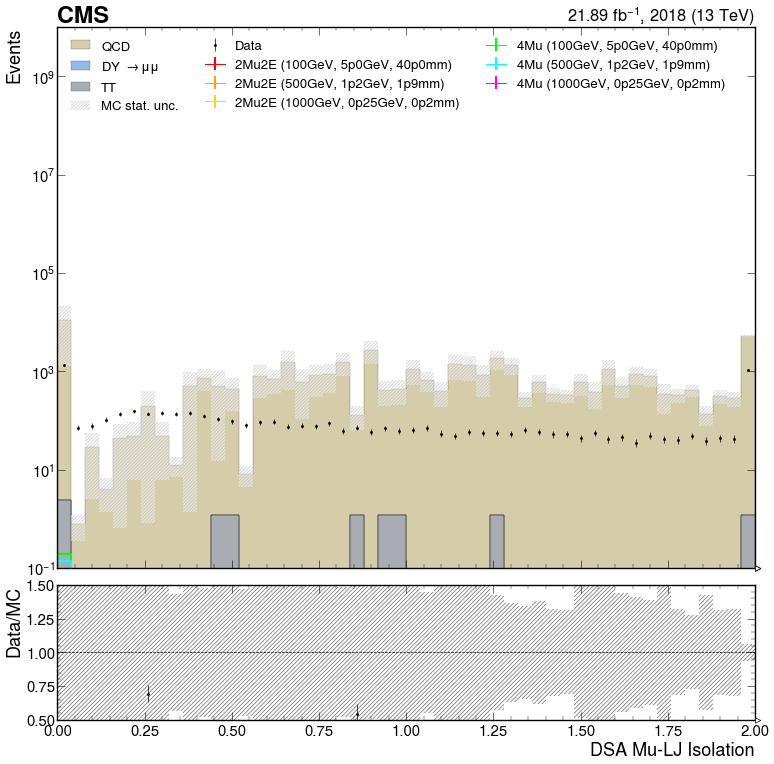

In [43]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_lj_isolation",
    xlabel=r"DSA Mu-LJ Isolation",
)

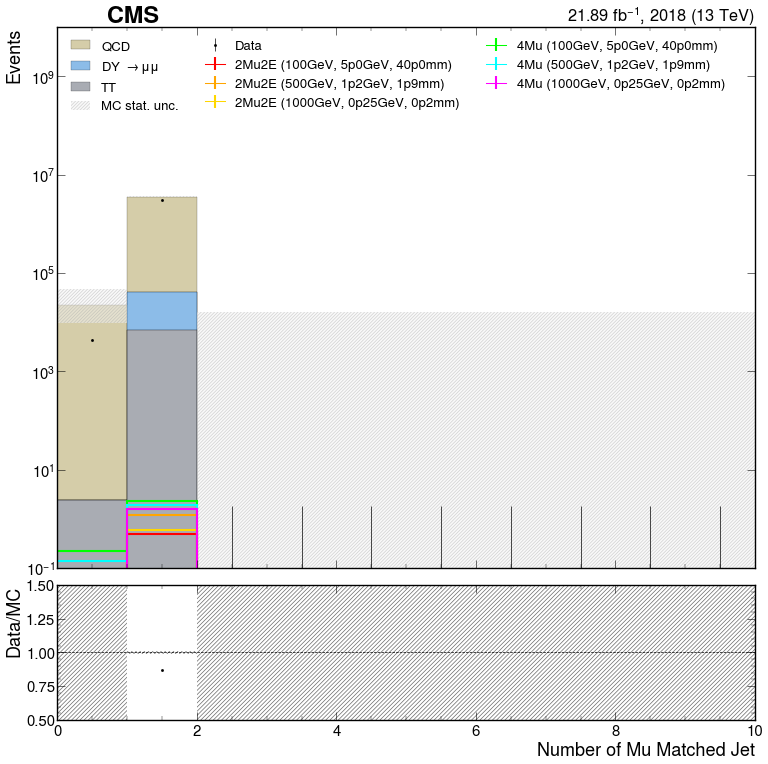

In [44]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_matched_jet_n",
    xlabel=r"Number of Mu Matched Jet",
)

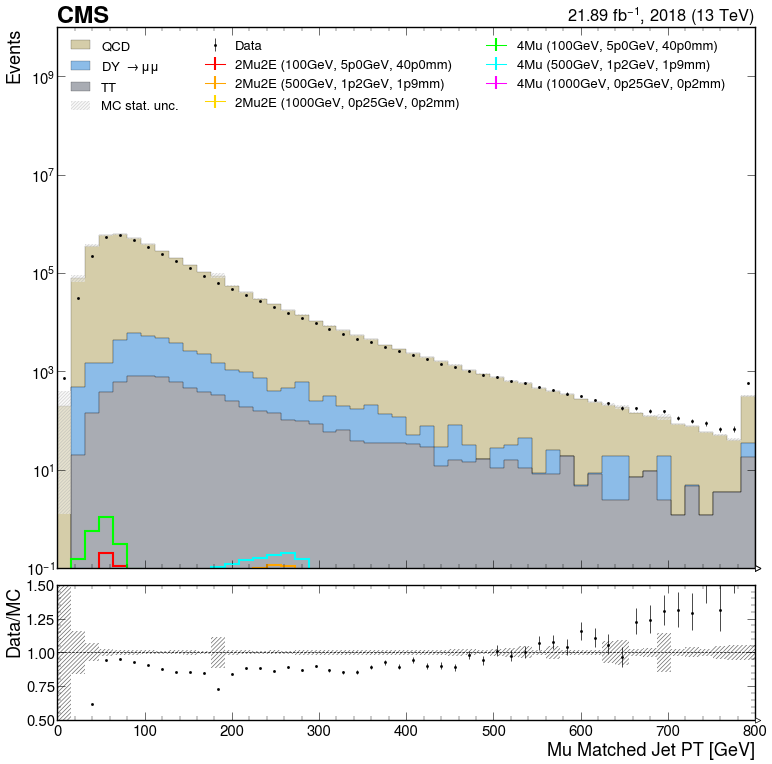

In [45]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_matched_jet_pt",
    xlabel=r"Mu Matched Jet PT [GeV]",
)

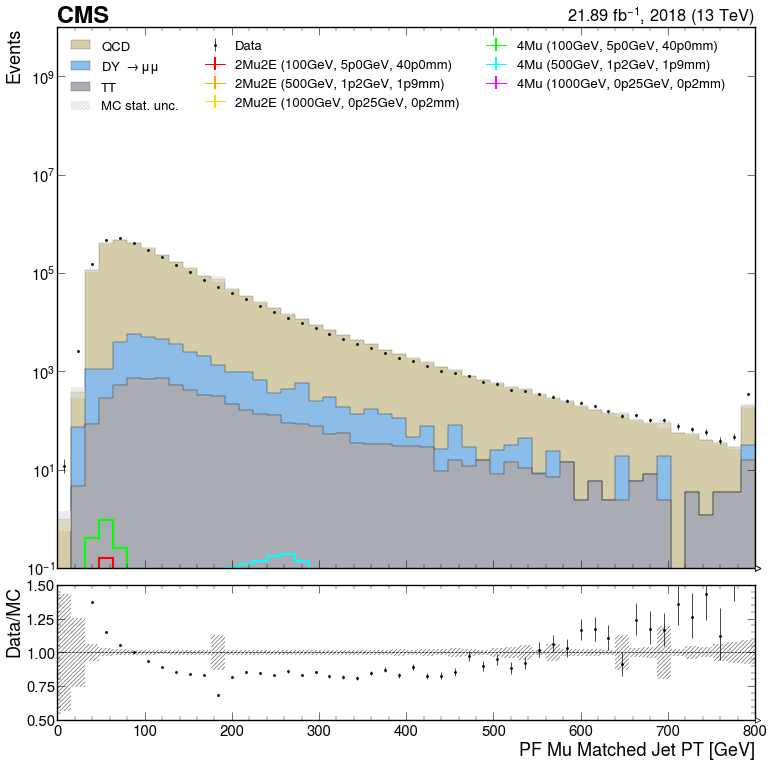

In [46]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_matched_jet_pt",
    xlabel=r"PF Mu Matched Jet PT [GeV]",
)

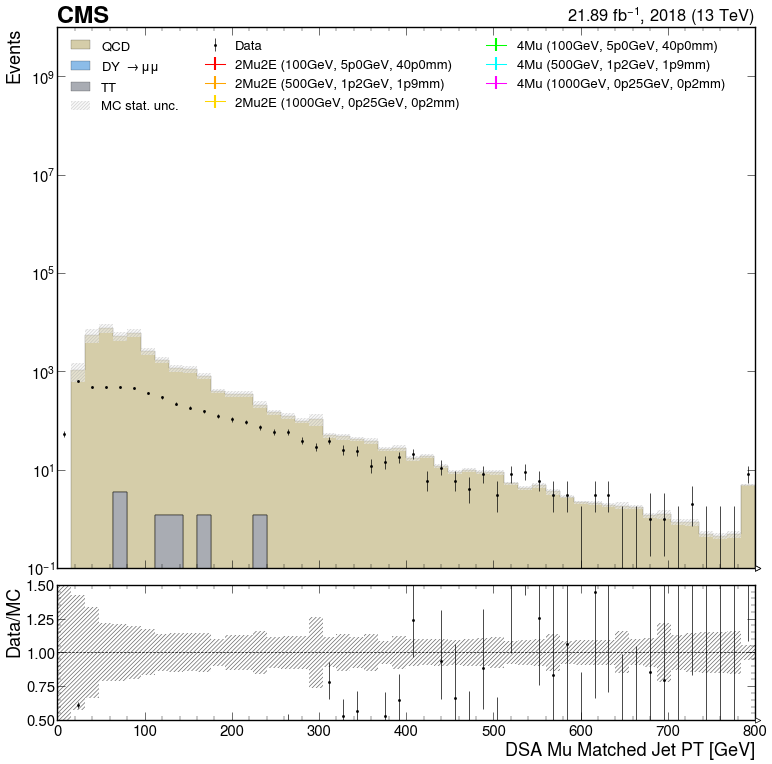

In [47]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_matched_jet_pt",
    xlabel=r"DSA Mu Matched Jet PT [GeV]",
)

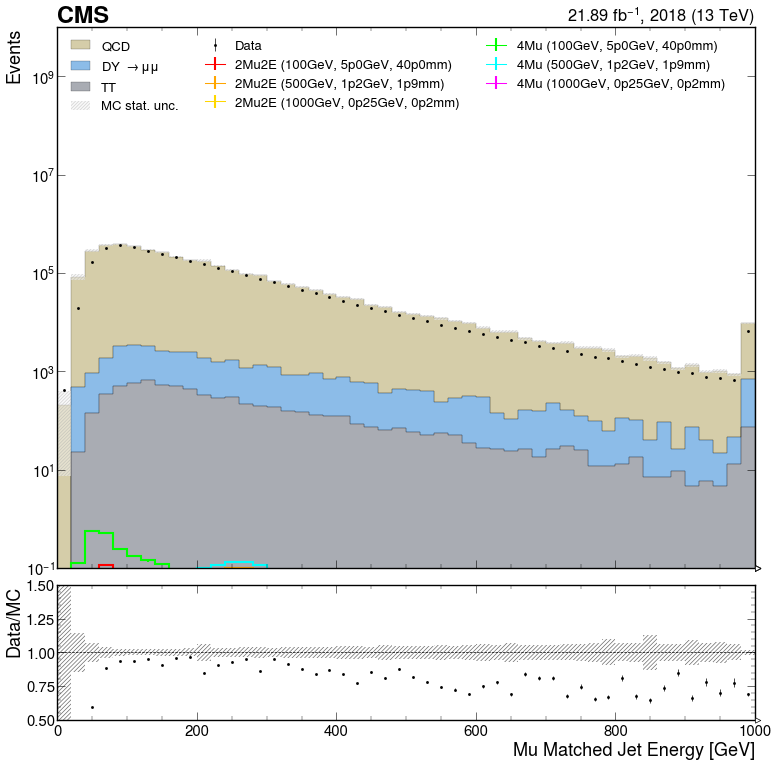

In [48]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_matched_jet_e",
    xlabel=r"Mu Matched Jet Energy [GeV]",
)

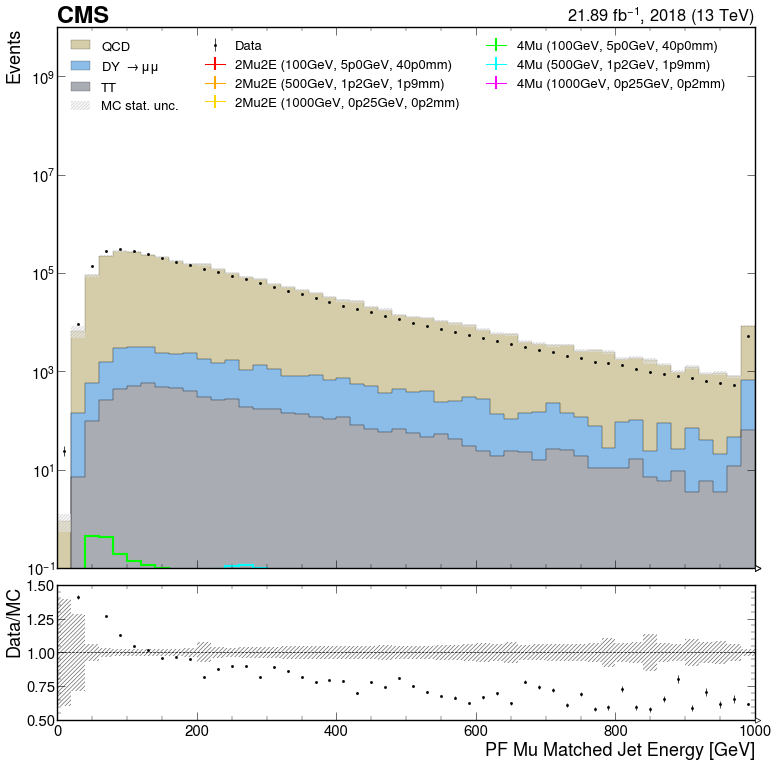

In [49]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_matched_jet_e",
    xlabel=r"PF Mu Matched Jet Energy [GeV]",
)

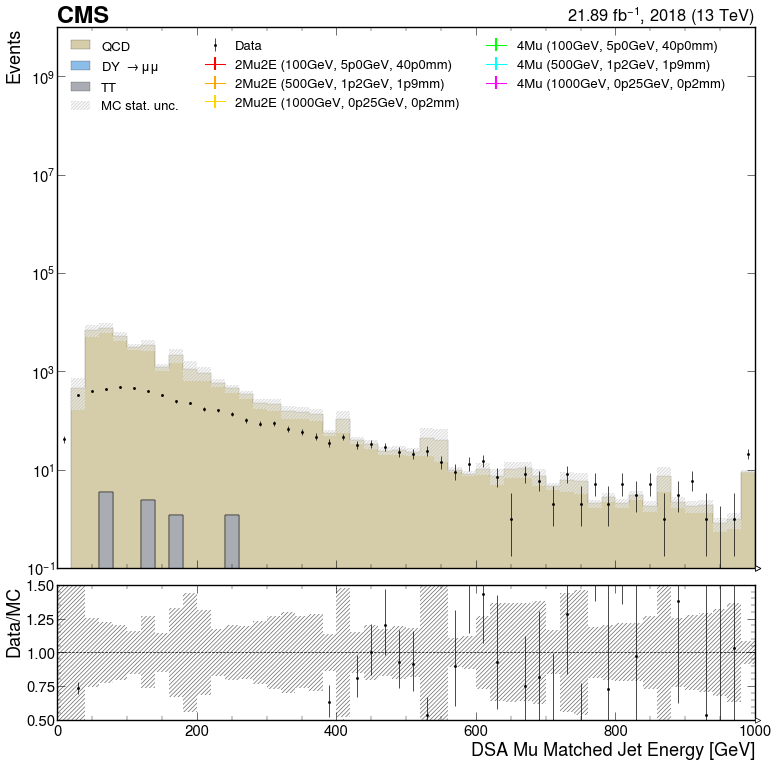

In [50]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_matched_jet_e",
    xlabel=r"DSA Mu Matched Jet Energy [GeV]",
)

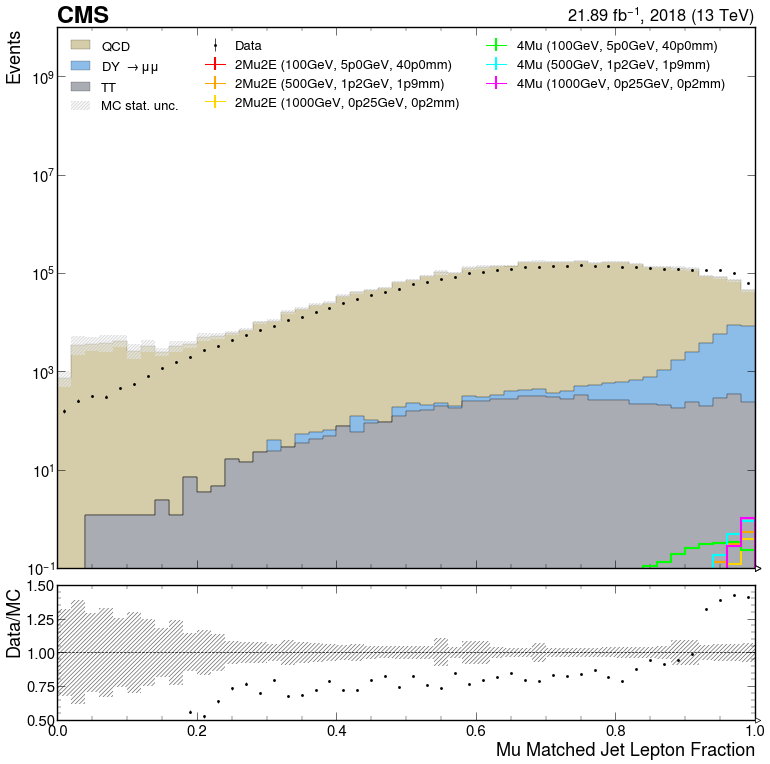

In [51]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_matched_jet_lepfraction",
    xlabel=r"Mu Matched Jet Lepton Fraction",
)

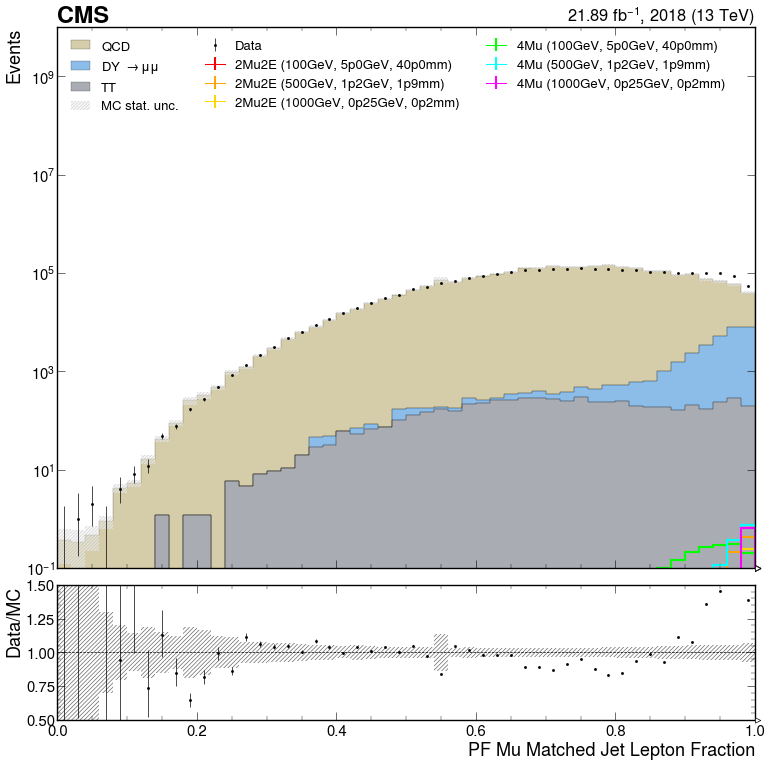

In [52]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_matched_jet_lepfraction",
    xlabel=r"PF Mu Matched Jet Lepton Fraction",
)

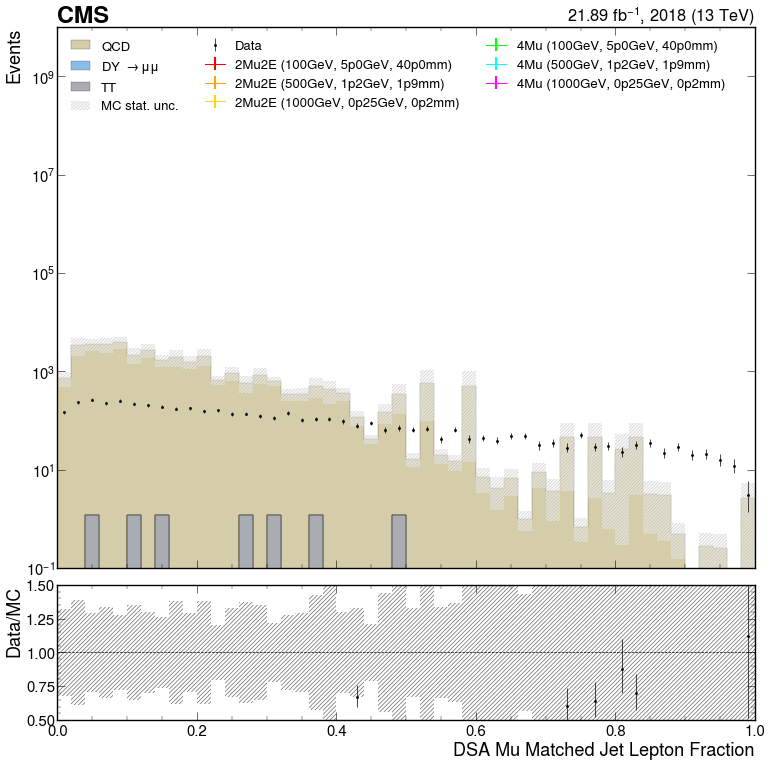

In [53]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_matched_jet_lepfraction",
    xlabel=r"DSA Mu Matched Jet Lepton Fraction",
)

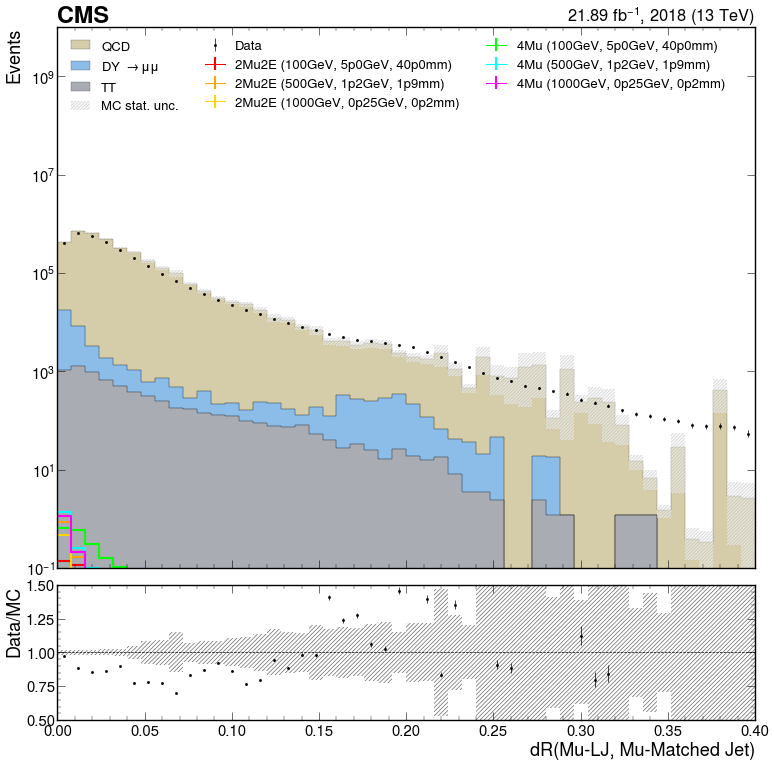

In [54]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_matched_jet_lj_dR",
    xlabel=r"dR(Mu-LJ, Mu-Matched Jet)",
)

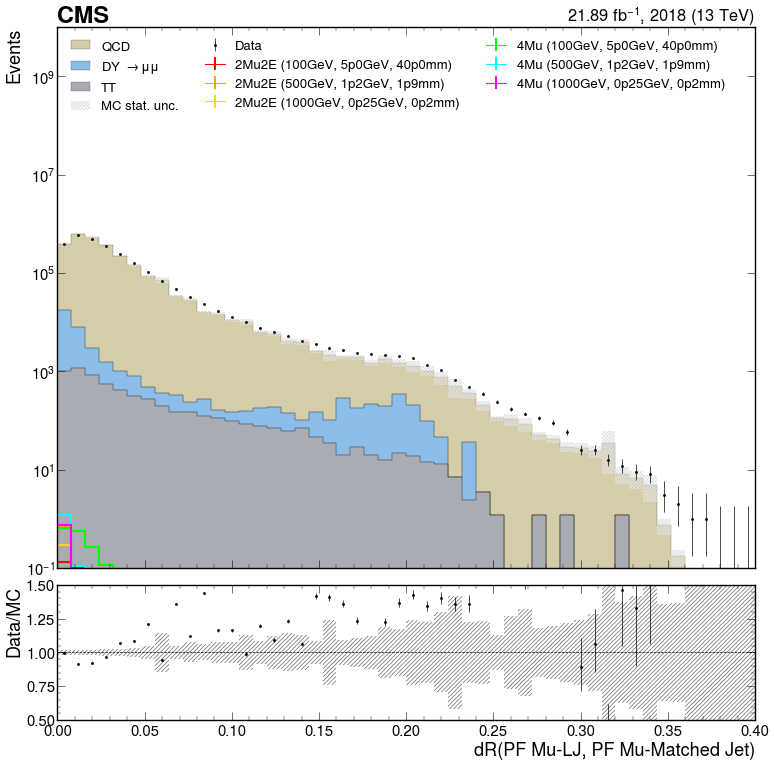

In [55]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_matched_jet_lj_dR",
    xlabel=r"dR(PF Mu-LJ, PF Mu-Matched Jet)",
)

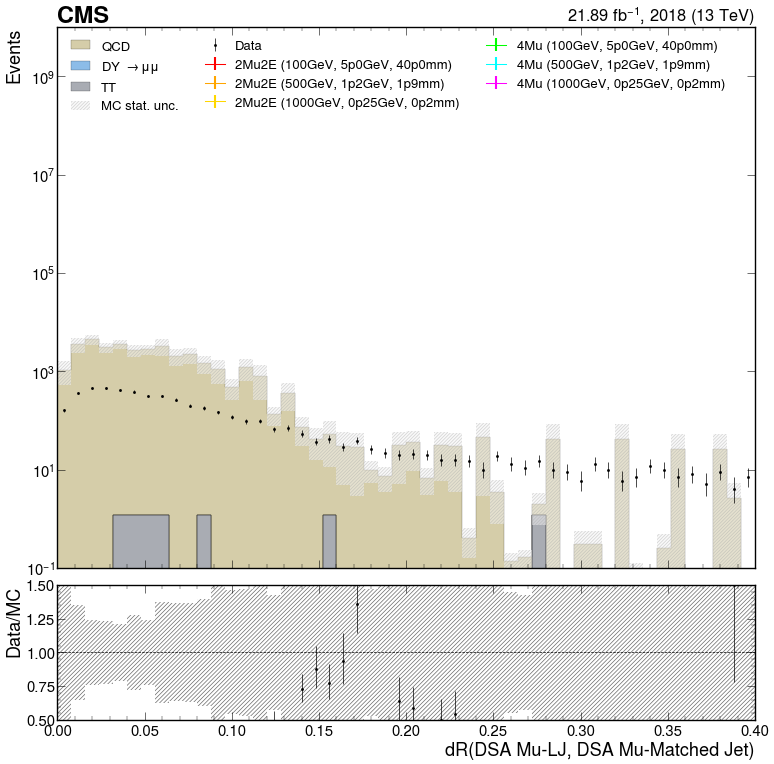

In [56]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_matched_jet_lj_dR",
    xlabel=r"dR(DSA Mu-LJ, DSA Mu-Matched Jet)",
)

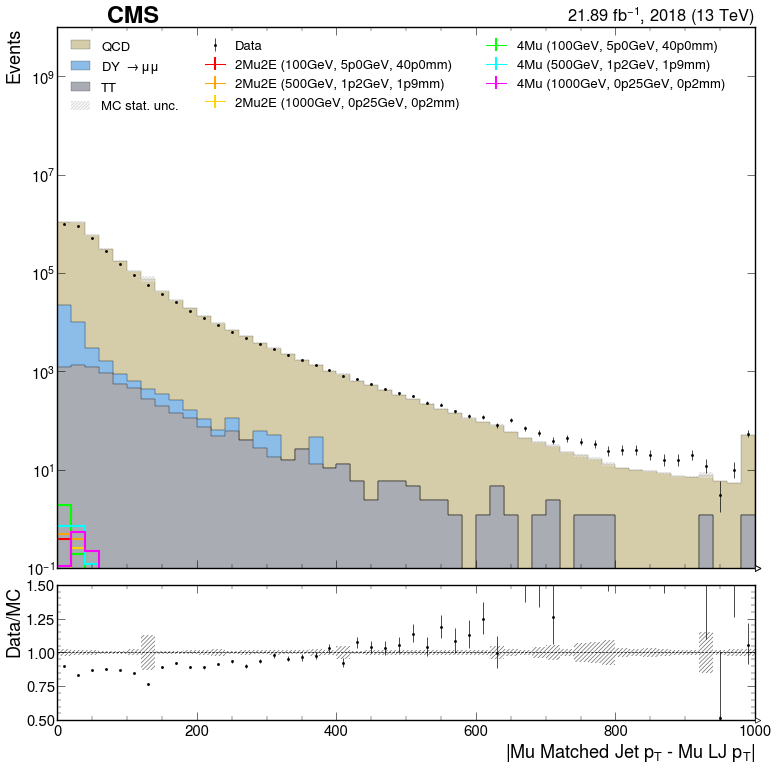

In [57]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dpt_mu_matched_jet_lj_large",
    xlabel=r"|Mu Matched Jet $p_{T}$ - Mu LJ $p_{T}$|",
)

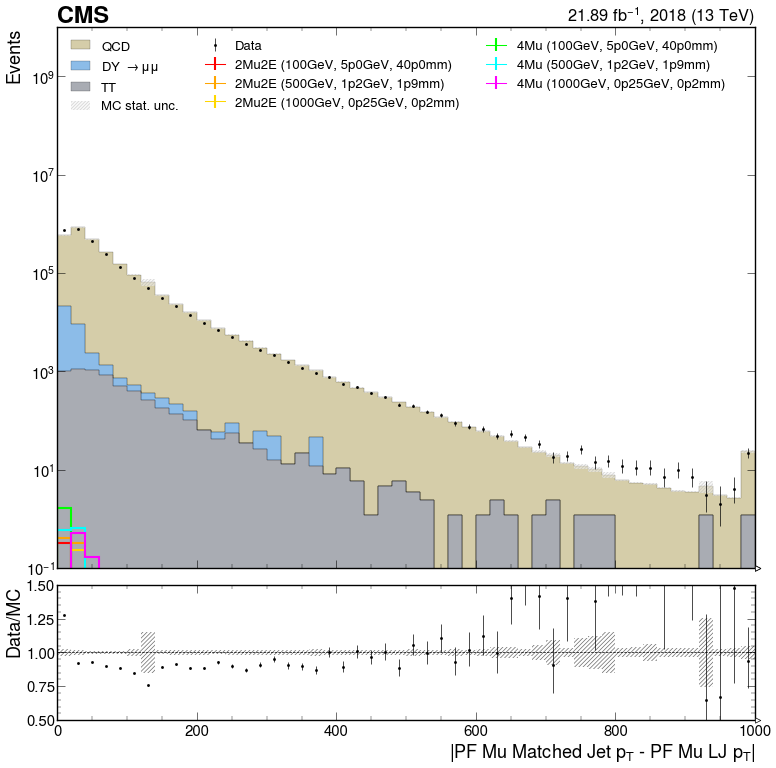

In [58]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dpt_pfmu_matched_jet_lj_large",
    xlabel=r"|PF Mu Matched Jet $p_{T}$ - PF Mu LJ $p_{T}$|",
)

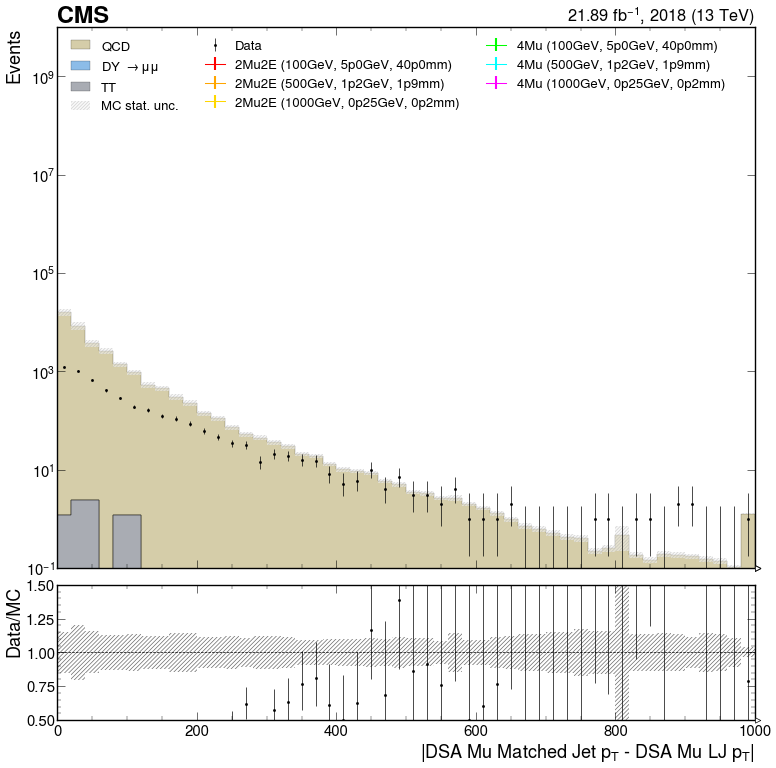

In [59]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dpt_dsamu_matched_jet_lj_large",
    xlabel=r"|DSA Mu Matched Jet $p_{T}$ - DSA Mu LJ $p_{T}$|",
)

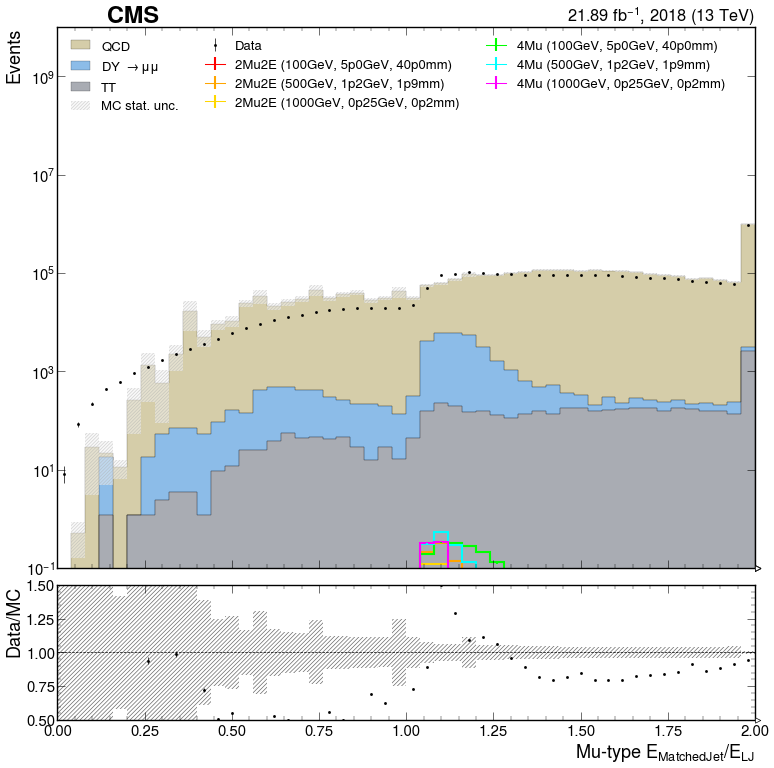

In [60]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="mu_mj_lj_Eratio",
    xlabel=r"Mu-type $E_{Matched Jet} / E_{LJ}$",
)

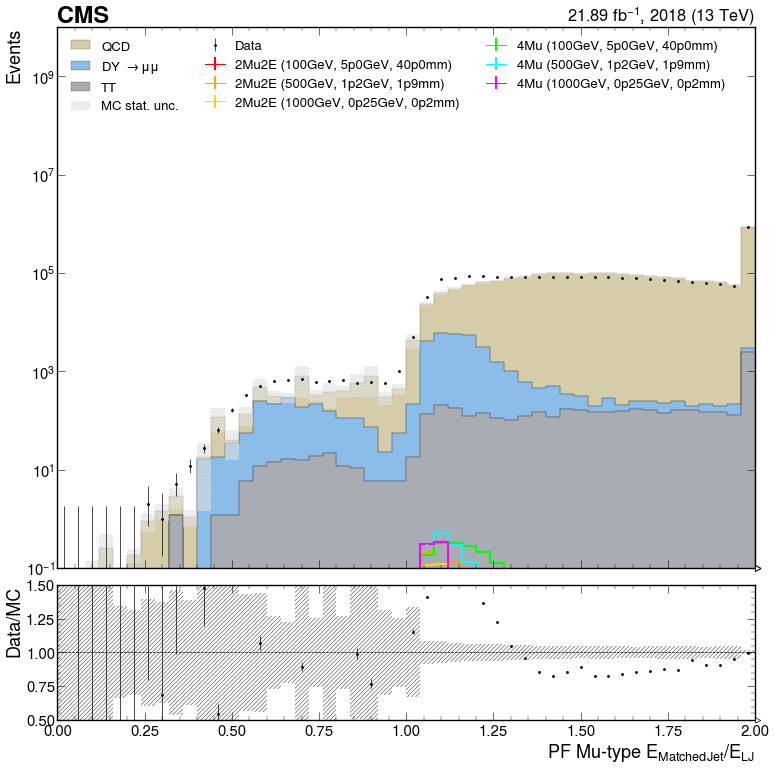

In [61]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="pfmu_mj_lj_Eratio",
    xlabel=r"PF Mu-type $E_{Matched Jet} / E_{LJ}$",
)

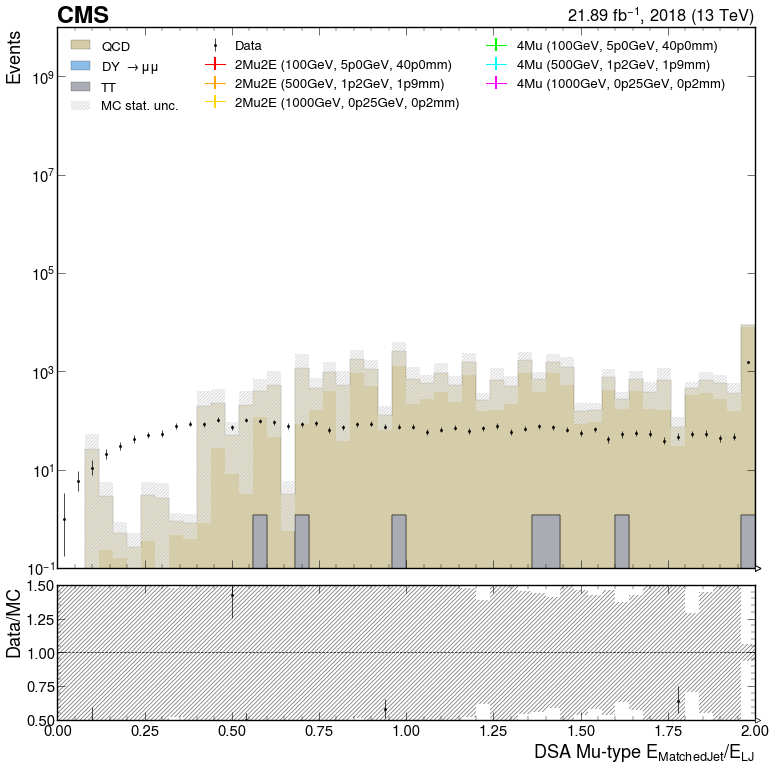

In [62]:
fig, ax_main, ax_ratio = plot_data_mc(
    out=out,
    out_data=out_data,
    channel=channels[0],
    data_samples=samples_data,
    backgrounds=backgrounds,
    background_colors=background_colors,
    signal_maps=signal_maps,
    year=2018,
    lumi=21.89,
    mc_lumi_scale=0.36584823474333794,
    logy=True,
    variable="dsamu_mj_lj_Eratio",
    xlabel=r"DSA Mu-type $E_{Matched Jet} / E_{LJ}$",
)